# Week 6 · Notebook 2 — MC Dropout and Deep Ensembles

## Learning objectives

1. Understand **Monte Carlo dropout** (Gal & Ghahramani 2016) as approximate variational inference in a BNN with a Bernoulli variational family.
2. Implement MC dropout in PyTorch and obtain predictive uncertainty by keeping dropout active at test time.
3. Implement a **deep ensemble** (Lakshminarayanan et al. 2017) of $M$ networks and compare its uncertainty to MC dropout and to the mean-field BNN from notebook 6.1.
4. Time the methods.

---

## 1. MC Dropout as variational inference

Apply dropout with rate $p$ to each layer. Each Bernoulli mask defines a different sub-network. Gal & Ghahramani show that minimising the standard $L_2$-regularised dropout loss is equivalent to minimising the KL between a Bernoulli variational posterior and the BNN's true posterior, under specific prior assumptions.

**Practical recipe:** turn dropout on at test time and average $T$ stochastic forward passes:
$$
\mathbb{E}[y_*] \approx \frac{1}{T}\sum_{t=1}^T f^{(t)}(x_*),\qquad
\mathrm{Var}[y_*] \approx \frac{1}{T}\sum_{t=1}^T f^{(t)}(x_*)^2 - \mathbb{E}[y_*]^2 + \sigma_n^2.
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

rng = np.random.default_rng(0)
torch.manual_seed(0)
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
BLUE, RED, GREEN = '#5B7DB1', '#C46D5E', '#7CA982'

def f_true(x): return x * np.sin(x)

X1 = rng.uniform(-5, -1, 25); X2 = rng.uniform(2, 6, 25)
X_np = np.concatenate([X1, X2])
y_np = f_true(X_np) + 0.3*rng.normal(size=len(X_np))
X = torch.tensor(X_np.reshape(-1, 1), dtype=torch.float32)
y = torch.tensor(y_np.reshape(-1, 1), dtype=torch.float32)
xs_np = np.linspace(-8, 9, 300)
Xs = torch.tensor(xs_np.reshape(-1, 1), dtype=torch.float32)


In [2]:
class MLPDropout(nn.Module):
    def __init__(self, hidden=64, p=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden), nn.Tanh(), nn.Dropout(p),
            nn.Linear(hidden, hidden), nn.Tanh(), nn.Dropout(p),
            nn.Linear(hidden, 1)
        )
    def forward(self, x): return self.net(x)

mcd = MLPDropout(hidden=64, p=0.15)
opt = torch.optim.Adam(mcd.parameters(), lr=5e-3, weight_decay=1e-4)
mcd.train()
for ep in range(2000):
    opt.zero_grad()
    loss = ((mcd(X) - y)**2).mean()
    loss.backward(); opt.step()

# Keep dropout active at test time!
mcd.train()
import time
t0 = time.time()
with torch.no_grad():
    preds = torch.stack([mcd(Xs).squeeze() for _ in range(200)], dim=0).numpy()
t_mcd = time.time() - t0
mu_mcd = preds.mean(0)
sd_mcd = preds.std(0)


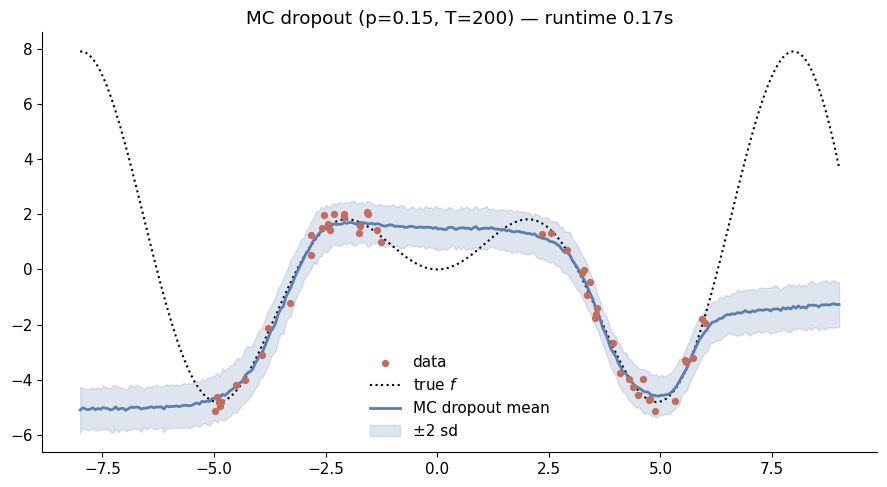

In [3]:
plt.figure()
plt.scatter(X_np, y_np, color=RED, s=18, zorder=5, label='data')
plt.plot(xs_np, f_true(xs_np), 'k:', label='true $f$')
plt.plot(xs_np, mu_mcd, color=BLUE, lw=2, label='MC dropout mean')
plt.fill_between(xs_np, mu_mcd-2*sd_mcd, mu_mcd+2*sd_mcd,
                 color=BLUE, alpha=0.2, label='±2 sd')
plt.legend(frameon=False)
plt.title(f'MC dropout (p=0.15, T=200) — runtime {t_mcd:.2f}s')
plt.tight_layout(); plt.show()


## 2. Deep ensembles

Train $M$ networks from different random initialisations on the same data. The diversity of their solutions (driven by stochastic optimisation, not by an explicit posterior) gives an empirical predictive distribution.


In [4]:
def train_one(seed, n_epochs=2000):
    torch.manual_seed(seed)
    net = nn.Sequential(nn.Linear(1, 64), nn.Tanh(),
                        nn.Linear(64, 64), nn.Tanh(),
                        nn.Linear(64, 1))
    opt = torch.optim.Adam(net.parameters(), lr=5e-3, weight_decay=1e-4)
    for _ in range(n_epochs):
        opt.zero_grad()
        loss = ((net(X) - y)**2).mean()
        loss.backward(); opt.step()
    net.eval()
    return net

t0 = time.time()
M = 10
ens = [train_one(seed=s) for s in range(M)]
t_ens = time.time() - t0
with torch.no_grad():
    preds_ens = torch.stack([net(Xs).squeeze() for net in ens], dim=0).numpy()
mu_ens = preds_ens.mean(0); sd_ens = preds_ens.std(0)


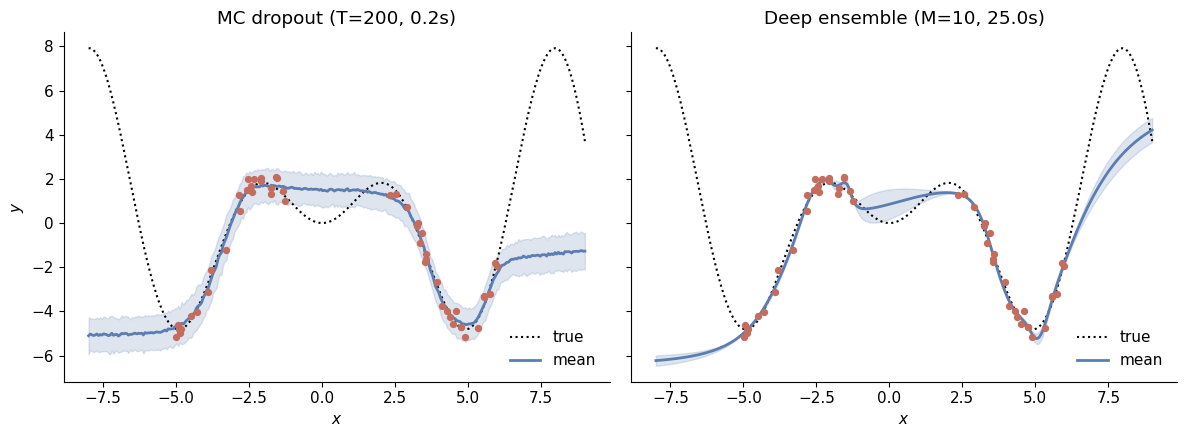

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, mu, sd, name in [(axes[0], mu_mcd, sd_mcd, f'MC dropout (T=200, {t_mcd:.1f}s)'),
                         (axes[1], mu_ens, sd_ens, f'Deep ensemble (M={M}, {t_ens:.1f}s)')]:
    ax.scatter(X_np, y_np, color=RED, s=18, zorder=5)
    ax.plot(xs_np, f_true(xs_np), 'k:', label='true')
    ax.plot(xs_np, mu, color=BLUE, lw=2, label='mean')
    ax.fill_between(xs_np, mu-2*sd, mu+2*sd, color=BLUE, alpha=0.2)
    ax.set_title(name); ax.set_xlabel('$x$'); ax.legend(frameon=False)
axes[0].set_ylabel('$y$')
plt.tight_layout(); plt.show()


## 3. Diagnostics — uncertainty as a function of $x$

Plot the standard deviation against $x$. Both methods should produce wider bands inside the gap and at the tails.


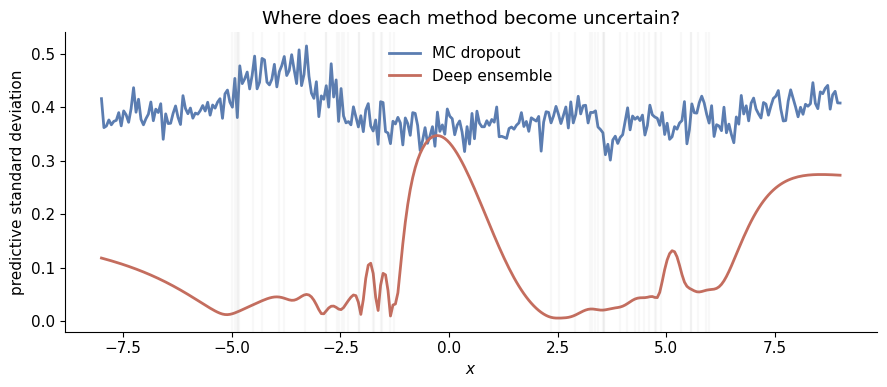

In [6]:
plt.figure(figsize=(9, 4))
plt.plot(xs_np, sd_mcd, color=BLUE, lw=2, label='MC dropout')
plt.plot(xs_np, sd_ens, color=RED,  lw=2, label='Deep ensemble')
for xi in X_np:
    plt.axvline(xi, color='gray', alpha=0.05)
plt.xlabel('$x$'); plt.ylabel('predictive standard deviation')
plt.title('Where does each method become uncertain?')
plt.legend(frameon=False); plt.tight_layout(); plt.show()


## 4. Pros and cons

| Method | Training cost | Inference cost | Pros | Cons |
|---|---|---|---|---|
| Mean-field VI (Bayes-by-backprop) | 1× (single net, 2× params) | $T$× | Principled, calibrated when posterior is roughly Gaussian | Underestimates variance, sensitive to prior |
| MC Dropout | 1× | $T$× | Trivially added to any net | Posterior tied to dropout rate; not flexible |
| Deep ensemble | $M$× | $M$× | Often best calibration in practice | $M$× compute and memory |

## 5. Summary

- MC dropout offers cheap, post-hoc uncertainty for any existing model.
- Deep ensembles are conceptually the simplest and often the most reliable in practice.
- Both can be combined with the calibration tooling from notebook 6.3.

---

## Exercises

1. Show analytically that for a fixed network architecture, the MC dropout predictive variance scales with $p$. Verify empirically by sweeping $p\in\{0.05, 0.1, 0.2, 0.4\}$.
2. Train deep ensembles where each member also predicts its own variance (heteroscedastic regression). How does this change the uncertainty plot?
3. Quantitatively compare BNN-VI, MC dropout, and a 10-member ensemble on held-out log-likelihood for a UCI regression dataset (e.g., `concrete`).
4. Combine MC dropout with an ensemble (5 networks each evaluated 20 times). Does this dominate either method alone?
